<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-hw-5?scriptVersionId=295516520" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [2]:
import torch  
from torchvision import datasets, transforms 

In [3]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
dataset = datasets.ImageFolder(data_dir)

In [4]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [5]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [6]:
img, label = data_train[2000]

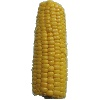

In [7]:
img

In [8]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [9]:
train_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
     transforms.ToTensor()
    ] 
)

In [10]:
train_transform(img).shape

torch.Size([3, 200, 200])

In [11]:
test_transform(img).shape

torch.Size([3, 200, 200])

In [12]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [13]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [14]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [15]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([42, 3, 200, 200])
torch.Size([42])


(200, 200, 3)


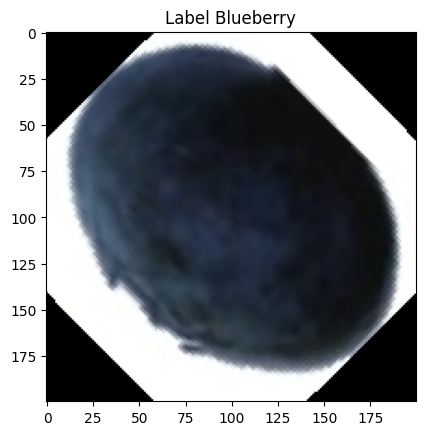

(200, 200, 3)


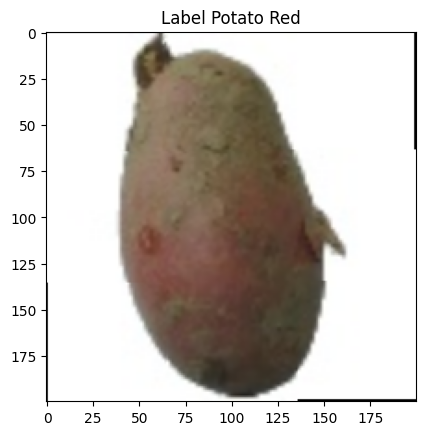

(200, 200, 3)


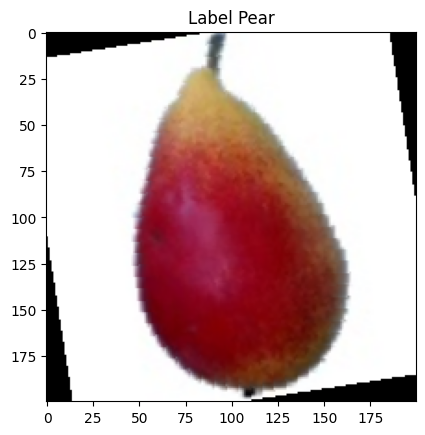

In [16]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

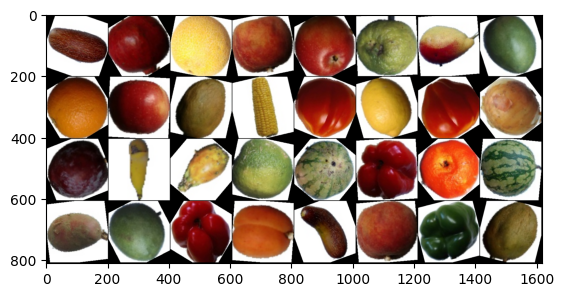

In [17]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [18]:
img, label = train_data[0]

img.shape

torch.Size([3, 200, 200])

In [19]:
3*200*200

120000

In [20]:
len(dataset.classes)

33

In [21]:
# from torch import nn

# #нейромережа
# model = nn.Sequential(
#     nn.Flatten(),   # переведе зображення 3х64х64 в нейрони 12288
#     nn.Linear(12288, 128),   # на вході 12288 нейронів передає інформацію 64 нейронам
#     nn.ReLU(),
#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Linear(64, 33)   # 33 нейрона на кожен тип фрукта
# )


# # підключення до процесора
# device = 'cuda'
# model = model.to(device)

3*200*200


from torch import nn

# Створення моделі
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),  # 8, 200, 200
    nn.ReLU(),
    nn.MaxPool2d(2, 2),    # 8, 100, 100
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),  # 16, 100, 100
    nn.ReLU(),
    nn.MaxPool2d(2, 2),    # 16, 50, 50
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), # 32, 50, 50
    nn.ReLU(),
    nn.MaxPool2d(2, 2),  # 32, 25, 25

    nn.Flatten(),  # 32*25*25 = 20000
    nn.Linear(20000, 32),
    nn.ReLU(),
    nn.Linear(32, 33)  # ← 33 класи фруктів
)


device = 'cuda'
model = model.to(device)


In [22]:
for imgs, labels in train_loader:
    break

In [23]:
imgs.shape

torch.Size([256, 3, 200, 200])

In [24]:
imgs = imgs.to(device)
res = model(imgs)
res.shape

torch.Size([256, 33])

In [25]:
# Взяти одне зображення з тестового набору
img, label = test_data[0]
img = img.unsqueeze(0).to(device)

# Передбачення
result = model(img)
predicted_class = result.argmax(dim=1).item()

print(f"Справжній клас: {label}")
print(f"Передбачений клас: {predicted_class}")
print(f"Назва: {dataset.classes[predicted_class]}")


Справжній клас: 26
Передбачений клас: 3
Назва: Avocado


In [26]:
#ймовірності
probs = nn.Softmax(dim=1)(result)
probs

tensor([[0.0306, 0.0301, 0.0276, 0.0365, 0.0357, 0.0270, 0.0307, 0.0280, 0.0274,
         0.0268, 0.0302, 0.0348, 0.0291, 0.0272, 0.0271, 0.0327, 0.0349, 0.0277,
         0.0299, 0.0288, 0.0287, 0.0287, 0.0285, 0.0267, 0.0288, 0.0329, 0.0336,
         0.0317, 0.0294, 0.0358, 0.0310, 0.0269, 0.0347]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [27]:
label

26

**# Визначення функції втрат та оптимізатора**

In [28]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),   
    lr=0.001
)

loss_list = []
loss_test_list = []
for i in range(10):
    
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 3.5038113594055176
loss: 3.5267062187194824
loss: 3.502896547317505
loss: 3.504045009613037
loss: 3.4884424209594727
loss: 3.4875266551971436
loss: 3.476815700531006
loss: 3.4679946899414062
loss: 3.4536166191101074
loss: 3.4483323097229004
loss: 3.3815221786499023
loss: 3.397475242614746
loss: 3.371938705444336
loss: 3.331733226776123
loss: 3.2339398860931396
loss: 3.2559332847595215
loss: 3.225656270980835
loss: 3.1365127563476562
loss: 3.119374990463257
loss: 3.0538578033447266
loss: 3.033964157104492
loss: 3.049429416656494
loss: 2.9290361404418945
loss: 2.9045920372009277
loss: 2.961953639984131
loss: 2.8580875396728516
loss: 2.915783643722534
loss: 2.791698694229126
loss: 2.699636936187744
loss: 2.6910552978515625
loss: 2.5347886085510254
loss: 2.6678643226623535
loss: 2.6732535362243652
loss: 2.4823155403137207
loss: 2.5632224082946777
loss: 2.2717204093933105
loss: 2.4195504188537598
loss: 2.3862977027893066
loss: 2.3251075744628906
loss: 2.3674073219299316
loss: 2.271788

In [29]:
print(model)  # Має показати архітектуру моделі

Sequential(
  (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=20000, out_features=32, bias=True)
  (11): ReLU()
  (12): Linear(in_features=32, out_features=33, bias=True)
)


In [30]:
import torch
dummy_input = torch.randn(1, 3, 200, 200)

torch.onnx.export(
    model.to('cpu'),
    dummy_input,
    'model.onnx',
    input_names=['image'],
    output_names=['result'],
    dynamic_axes={"image": {0: "batch_size"}, "result": {0: "batch_size"}}
)
print("Модель експортована в model.onnx")


/tmp/ipykernel_55/3324125107.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Модель експортована в model.onnx


In [31]:
# Перевір чи модель існує
print("Модель існує:", 'model' in dir())

# Перемісти модель на GPU (якщо вона на CPU після ONNX експорту)
device = 'cuda'
model = model.to(device)

# Збережи модель
torch.save(model.state_dict(), 'fruit_cnn_model.pth')
print("✅ Файл fruit_cnn_model.pth збережено!")

# Перевір що файл створився
import os
if os.path.exists('fruit_cnn_model.pth'):
    print("✅ Файл знайдено!")
    print(f"Розмір: {os.path.getsize('fruit_cnn_model.pth')} байт")
else:
    print("❌ Файл НЕ створився!")

Модель існує: True
✅ Файл fruit_cnn_model.pth збережено!
✅ Файл знайдено!
Розмір: 2592965 байт


In [32]:
model = model.to(device)  # Повертаємо модель на GPU

img, label = train_data[0]
img = img.unsqueeze(0).to(device)
prediction = model(img)

print(label)
print(nn.Softmax(dim=1)(prediction))

5
tensor([[4.6496e-31, 1.1174e-24, 0.0000e+00, 1.9371e-03, 1.2734e-33, 9.9751e-01,
         6.1474e-06, 1.1193e-24, 2.6595e-11, 5.2675e-34, 1.1872e-21, 3.3418e-07,
         1.4305e-06, 3.3751e-24, 4.1133e-35, 1.2061e-26, 8.6016e-09, 3.3728e-26,
         9.8091e-45, 1.0763e-16, 8.5709e-15, 8.3587e-30, 5.3444e-24, 3.0260e-04,
         2.4275e-16, 2.2810e-04, 4.6354e-16, 2.1151e-13, 1.4875e-07, 2.5502e-08,
         8.2695e-07, 7.3212e-27, 8.9579e-06]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


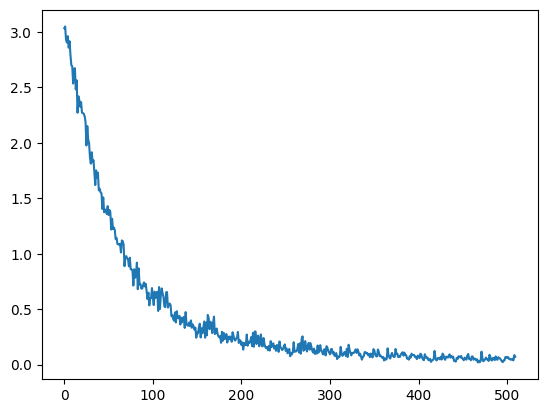

In [33]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)

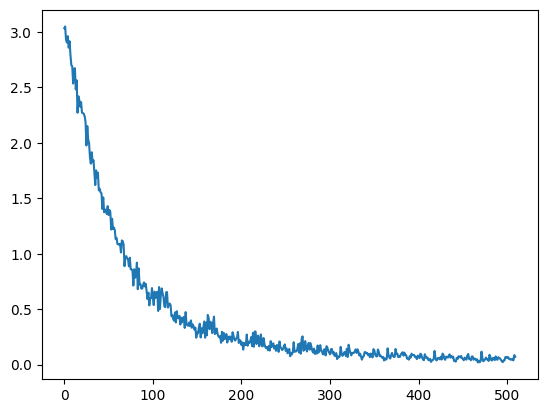

In [34]:
plt.plot(new_list)

In [35]:
imgs.shape

torch.Size([42, 3, 200, 200])

In [36]:
result = model(imgs)

In [37]:
result.argmax(dim=1)

tensor([ 7,  7,  8, 30, 31,  6, 31,  8, 17, 11, 10, 11, 24,  9, 18, 28, 14,  9,
        21, 22, 22, 14, 31, 31, 12,  4,  3, 17, 28, 12, 18,  2, 12, 20, 19, 12,
        25,  4, 12, 13, 12,  1], device='cuda:0')

In [38]:
labels

tensor([ 7,  7,  8, 30, 31,  6, 31,  8, 17, 11, 10, 11, 24,  9, 18, 28, 14,  9,
        21, 22, 22, 14, 31, 31, 12,  4,  3, 17, 28, 12, 18,  2, 12, 20, 19,  5,
        25,  4, 12, 13, 12,  1], device='cuda:0')

In [39]:
res1 = result.argmax(dim=1)
res2 = res1 == labels

In [40]:
res2.sum()

tensor(41, device='cuda:0')

In [41]:
count = 0
for imgs, labels in test_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count)
print(f"Всього test: {len(test_data)}")
print(f"Accuracy: {count/len(test_data):.4f}")

3338
Всього test: 3370
Accuracy: 0.9905


In [42]:
count = 0
for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count)
print(f"Всього test: {len(train_data)}")
print(f"Accuracy: {count/len(train_data):.4f}")

13354
Всього test: 13484
Accuracy: 0.9904
